In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd

hpd.util.get_color_logger("INFO")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

**Het extent is in Rijksdriehoek (xmin, xmax, ymin, ymax). Meetpunten binnen dit extent worden ingeladen.**

**Met het `which-timeseries` argument kun je de bron van de grondwatermetingen selecteren:** 
- Hand is handmatig gemeten door een persoon
- Diver is gemeten met een sensor
- Diver_validated is gemeten met een sensor en gevalideerd door de databeheerder

In [3]:
my_extent = (89945, 91552, 440688, 441553) 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 10
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|█████████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.87it/s]


In [13]:
oc.plots.interactive_map(
    color="red",
    zoom_start=15,
    tiles="Esri.WorldImagery",
    popup_width=350
)

**Deze tabel toont de `ObsCollection` met alle grondwatermeetpunten die binnen het opgegeven extent zijn ingeladen via de Lizard API.**  
**Elke rij vertegenwoordigt één peilbuis met bijbehorende metadata (zoals locatie, filterdiepte en maaiveldhoogte) en een koppeling naar de bijbehorende tijdreeks (`GroundwaterObs`).**

In [4]:
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs
name,,,,,,,,,,,,,
GMW000000036741001,90998.687871,441239.318459,MEIJPL-12,,lizard,m NAP,1,-15.680,-16.680,-4.560,-2.680,True,GroundwaterObs GMW000000036741001 -----metadat...
GMW000000036965001,91525.037726,441090.628347,128572-792,,lizard,m NAP,1,-5.970,-6.970,-4.850,-4.970,True,GroundwaterObs GMW000000036965001 -----metadat...
GMW000000036989001,90664.868686,441145.728338,127572-1,,lizard,m NAP,1,-5.150,-7.150,-4.340,-4.350,True,GroundwaterObs GMW000000036989001 -----metadat...
GMW000000037445001,90407.518334,440789.329306,127571-4,,lizard,m NAP,1,-5.390,-7.390,-4.830,-4.890,True,GroundwaterObs GMW000000037445001 -----metadat...
GMW000000038220001,91303.067938,441217.968233,128572-795,,lizard,m NAP,1,-16.560,-18.560,-4.680,-3.560,True,GroundwaterObs GMW000000038220001 -----metadat...
GMW000000098093001,91547.087277,441459.765282,128572-798,,lizard,m NAP,1,-6.807,-7.807,-4.807,-4.884,True,GroundwaterObs GMW000000098093001 -----metadat...
GMW000000101405001,91513.987745,441096.026782,128572-9,,lizard,m NAP,1,-6.410,-7.410,-4.860,-4.860,True,GroundwaterObs GMW000000101405001 -----metadat...
GMW000000101406001,91466.987589,441235.026233,128572-12,,lizard,m NAP,1,-6.390,-7.390,-4.840,-4.840,True,GroundwaterObs GMW000000101406001 -----metadat...
GMW000000101454001,91522.988168,440812.027927,128571-3,,lizard,m NAP,1,-6.390,-7.390,-4.740,-4.740,True,GroundwaterObs GMW000000101454001 -----metadat...


**In deze stap wordt één specifieke peilbuis geselecteerd uit de ObsCollection op basis van de unieke well code.**

In [5]:
gw = oc.obs["GMW000000036965001"]
print(gw)

GroundwaterObs GMW000000036965001
-----metadata------
name : GMW000000036965001 
x : 91525.03772620695 
y : 441090.6283468774 
location : 128572-792 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -5.97 
screen_bottom : -6.97 
ground_level : -4.85 
tube_top : -4.97 
metadata_available : True 

-----time series------
                     value  flag        comment           origin
peil_datum_tijd                                                 
2011-11-15 00:00:00 -5.960   NaN        Gemeten             hand
2012-01-17 14:58:00 -5.870   NaN        Gemeten             hand
2012-03-12 10:02:00 -5.890   NaN        Gemeten             hand
2012-05-09 23:00:00 -5.760   NaN        Gemeten             hand
2012-07-13 19:59:00 -5.830   NaN        Gemeten             hand
2012-11-05 00:00:00 -5.690   NaN        Gemeten             hand
2013-01-13 17:43:00 -5.790   NaN        Gemeten             hand
2013-02-15 17:58:00 -5.750   NaN        Gemeten             hand
2013-03-0

**Hier wordt de grondwaterstandtijdreeks uit de geselecteerde peilbuis geëxtraheerd en opgeschoond:**

- De kolom "value" (grondwaterstand) wordt gekopieerd uit het `GroundwaterObs` object  
- De datums worden omgezet naar pandas datetimes zodat tijdreeks bewerkingen mogelijk zijn  
- Ontbrekende metingen (NaN-waarden) worden verwijderd

**Tot slot wordt gecontroleerd:**
- Wat de eerste en laatste meetdatum zijn  
- Hoeveel metingen de tijdreeks bevat  

In [6]:
ts = gw["value"].copy()
ts.index = pd.to_datetime(ts.index)
ts = ts.dropna()

print(ts.index.min(), ts.index.max())
print(ts.shape)

2011-11-15 00:00:00 2025-12-16 01:25:36
(7769,)


**In deze stap wordt de tijdreeks eerst beperkt tot de gekozen analyseperiode. Vervolgens wordt de reeks omgerekend naar dagelijkse waarden, waarbij bij meerdere metingen op één dag het daggemiddelde wordt gebruikt. Dit zorgt ervoor dat de tijdreeks maximaal één waarde per dag bevat en consistent is voor verdere analyse.**

**Daarna worden ontbrekende dagwaarden automatisch lineair geïnterpoleerd (`.interpolate`). Hierbij worden alleen de bestaande meetwaarden vóór en na ontbrekende waardes gebruikt om ontbrekende dagen aan te vullen.**

**Tot slot wordt vastgelegd welke dagen zijn geïnterpoleerd. Dit maakt het mogelijk om later transparant te rapporteren hoeveel en welke dagen geen oorspronkelijke meting bevatten, maar zijn afgeleid via interpolatie.**

In [7]:
ts_year = ts.loc["2024-11-01":"2025-10-31"]

ts_daily_raw = ts_year.resample("D").mean()

ts_daily = ts_daily_raw.interpolate(method="time")

is_interpolated = ts_daily_raw.isna()

**In deze stap wordt de vaste droogtedrempel bepaald op basis van een gekozen percentiel van de grondwaterstanden binnen de analyseperiode.**

**Eerst wordt het percentiel numeriek berekend, wat resulteert in één drempelwaarde (in m NAP). Vervolgens wordt een overzichtstabel opgebouwd op basis van de ruwe grondwatermetingen.** **Deze tabel is gesorteerd van lage naar hoge waarden en laat per observatie zien:**
- de rangorde binnen de verdeling,
- de cumulatieve fractie van de dataset,
- of de waarde onder de vastgestelde droogtedrempel valt.

**Deze tabel maakt inzichtelijk hoe het percentiel tot stand komt en welke waarnemingen bijdragen aan de bepaling van de droogtedrempel.**


In [8]:
percentile = 0.30
threshold_fixed = ts_year.quantile(percentile)

## COMMENT VOOR VARIABLE THRESHOLD
# df_pct = (
#     ts_year
#     .sort_values()
#     .to_frame(name="value")
#     .reset_index(names="date")
# )

# df_pct["rank"] = range(1, len(df_pct) + 1)
# df_pct["cum_frac"] = df_pct["rank"] / len(df_pct)
# df_pct["below_threshold"] = df_pct["value"] <= threshold_fixed

# print(f"Fixed threshold (30th percentile): {threshold_fixed:.2f} m NAP")

# df_pct

# VARIABLE threshold – stap 1: percentiel per maand
monthly_threshold = (
    ts_year
    .groupby(ts_year.index.month)
    .quantile(0.30)
)

# VARIABLE threshold – stap 2: toekennen aan elke dag
threshold_variable = ts_daily.index.to_series().map(
    lambda d: monthly_threshold.loc[d.month]
)

# VARIABLE threshold – stap 3: smoothing (20 dagen, backwards)
threshold_variable_smooth = (
    threshold_variable
    .rolling(window=20, min_periods=1)
    .mean()
)

# COMMENT VOOR GEKOZEN THRESHOLD
# threshold = threshold_fixed
threshold = threshold_variable_smooth

**Een dag wordt als "droogtedag" geclassificeerd wanneer de dagelijkse grondwaterstand lager is dan de vastgestelde droogtedrempel**

In [9]:
is_drought = ts_daily < threshold

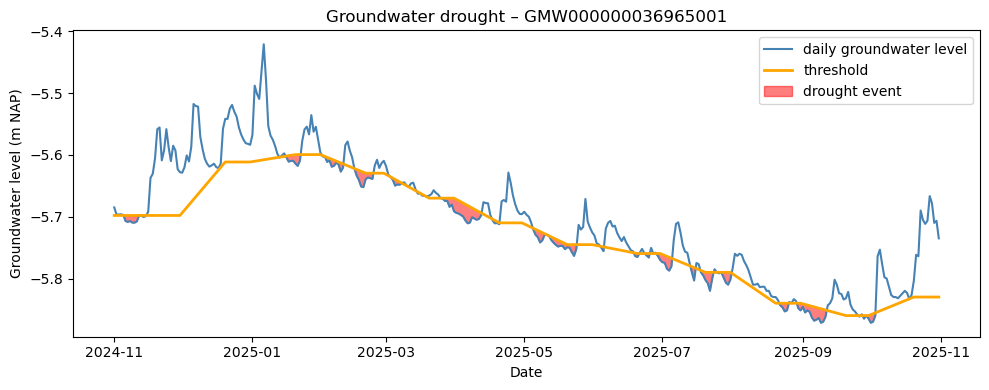

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    ts_daily.index,
    ts_daily,
    color="steelblue",
    linewidth=1.5,
    label="daily groundwater level",
)

if isinstance(threshold, (int, float)):
    ax.axhline(threshold, color="orange", linewidth=2, label="threshold")
else:
    ax.plot(
        threshold.index,
        threshold.values,
        color="orange",
        linewidth=2,
        label="threshold",
    )

ax.fill_between(
    ts_daily.index,
    ts_daily,
    threshold,
    where=is_drought,
    color="red",
    alpha=0.5,
    label="drought event",
    interpolate=True,
)

ax.set_ylabel("Groundwater level (m NAP)")
ax.set_xlabel("Date")
ax.set_title(f"Groundwater drought – {gw.name}")
ax.legend()

plt.tight_layout()
plt.show()


**In deze stap worden de droogteduur, het maximale tekort en het aantal
geïnterpoleerde dagen berekend voor de analyseperiode.**

In [11]:
duration_days = is_drought.sum()
max_deficit = (threshold - ts_daily[is_drought]).max()

n_interpolated = is_interpolated.sum()

print(
    f"Drought duration (2024–2025): {duration_days} days. "
    f"{n_interpolated} days were interpolated."
)
print(f"Maximum deficit (2024–2025): {max_deficit:.2f} m")

Drought duration (2024–2025): 136 days. 2 days were interpolated.
Maximum deficit (2024–2025): 0.03 m


**In deze laatste stap wordt per dag vastgelegd wat de herkomst van de
grondwatermeting is (hand, diver of diver_validated) en of de
dagwaarde is gebaseerd op interpolatie.**

In [12]:
origin_per_day = (
    gw[["value", "origin"]]
    .dropna()
    .assign(date=lambda df: df.index.normalize())
    .groupby("date")["origin"]
    .agg(lambda x: ",".join(sorted(set(x))))
)

summary = pd.DataFrame({
    "value": ts_daily,
    "interpolated": is_interpolated
})

summary["origin"] = origin_per_day
summary.loc[summary["interpolated"], "origin"] = "interpolated"

summary

# satellietdataportaal
# groenmonitor wageningen universiteit

,value,interpolated,origin
peil_datum_tijd,,,
2024-11-01,-5.685000,False,diver_validated
2024-11-02,-5.696500,False,diver_validated
2024-11-03,-5.696500,False,diver_validated
2024-11-04,-5.696167,False,diver_validated
2024-11-05,-5.697167,False,diver_validated
2024-11-06,-5.707167,False,diver_validated
2024-11-07,-5.708500,False,diver_validated
2024-11-08,-5.707000,False,diver_validated
2024-11-09,-5.709667,False,diver_validated
